# Notebook 04: Ensemble Stochastic Forecasting, MBC, and Life Expectancy

## Overview
This notebook generates stochastic longevity projections for the 6-country frontier cluster from 2020 to 2050, using a **5-model ensemble** trained in Notebook 03. It produces sex-specific projections (Male and Female) with a properly calibrated dual uncertainty framework.

## Key Methodological Improvements

### 1. Residual-Calibrated Process Noise (No Double-Counting)
The process noise σ is calibrated on the model's **walk-forward one-step-ahead residuals**, not on the full historical variability of Li-Lee first differences. This avoids double-counting: the LSTM already captures a portion of the historical variability through its learned predictions. The residual σ isolates the *irreducible* uncertainty that the model cannot explain.

### 2. Ensemble Averaging (Model Robustness)
Instead of relying on a single model (Seed 42), we average MC Dropout predictions across 5 independently trained models. This is equivalent to credibility pooling — each model learns slightly different representations due to different weight initialisations, and the average cancels seed-specific artefacts while preserving the shared mortality signal.

## Objectives
1. **Residual Calibration**: Compute walk-forward one-step-ahead residuals to derive the corrected process noise σ.
2. **Ensemble MC Dropout Forecasting**: Generate 200 stochastic trajectories per model × 5 models = 1,000 effective trajectories.
3. **Dual Uncertainty**: Combine MC Dropout (model uncertainty) with residual-calibrated process noise (aleatoric uncertainty).
4. **Level Reconstruction & MBC**: Integrate first-difference forecasts and apply Mean-Bias Correction.
5. **Life Expectancy ($e_0$)**: Reconstruct stochastic mortality surfaces and compute $e_0$ for all 6 countries × 2 sexes.
6. **Persistence**: Save all results for downstream analysis (Notebooks 05-06).


## 4.1: Setup & Asset Loading

In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed, get_seed_list
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, logging, warnings, time
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
from tensorflow import keras
import joblib

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style("notebook")

PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"
FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load training metadata
with open(os.path.join(PROCESSED_DIR, "training_meta.pkl"), "rb") as f:
    meta = pickle.load(f)

LOOKBACK = meta["lookback"]
N_FEATURES = meta["n_features"]
TRAIN_SPLIT_IDX = meta["train_split_idx"]
SEEDS = meta["ensemble_seeds"]

# Load scaler
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler_joint.pkl"))

# Load ensemble models
ensemble_models = {}
for seed in SEEDS:
    path = os.path.join(MODELS_DIR, f"ainn_seed_{seed}.keras")
    ensemble_models[seed] = keras.models.load_model(path, compile=False)

# Load Li-Lee parameters
with open(os.path.join(PROCESSED_DIR, "li_lee_params.pkl"), "rb") as f:
    bundle = pickle.load(f)

feature_matrices = bundle["feature_matrices"]
common_factors = bundle["common_factors"]
YEARS = bundle["metadata"]["years"]
AGES = bundle["metadata"]["ages"]
N_AGES = len(AGES)

print(f"Ensemble loaded: {len(ensemble_models)} models (seeds: {SEEDS})")
print(f"Config: lookback={LOOKBACK}, features={N_FEATURES}")
print(f"Li-Lee: Years {YEARS[0]}-{YEARS[-1]}, Ages {AGES[0]}-{AGES[-1]}")
print(f"Cluster: {list(COUNTRIES.keys())}")
print(f"\nPer-seed RMSE (from NB03):")
for seed, rmse in meta['ensemble_seed_rmses'].items():
    marker = ' ← champion' if int(seed) == 42 else ''
    print(f"  Seed {seed}: {rmse:.4f}{marker}")
print(f"  CV: {meta['multi_seed_cv']:.2f}%")

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ensemble loaded: 5 models (seeds: [42, 77, 256, 512, 1024])
Config: lookback=15, features=8
Li-Lee: Years 1956-2020, Ages 0-90
Cluster: ['CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN']

Per-seed RMSE (from NB03):
  Seed 42: 6.1725 ← champion
  Seed 77: 6.3193
  Seed 256: 6.3032
  Seed 512: 6.2459
  Seed 1024: 6.3340
  CV: 1.06%


## 4.2: Process Noise Calibration (Walk-Forward Residuals)

We compute one-step-ahead residuals using the champion model (Seed 42) deterministically (`training=False`). For each time step $t \geq$ `lookback`, the preceding `lookback` observations serve as input.

The residual $r_t = \Delta K_t^{observed} - \Delta K_t^{predicted}$ isolates what the model cannot predict. The standard deviation $\sigma_{residual} = \text{std}(r_t)$ is the correct process noise — it excludes the variability the LSTM already captures, avoiding double-counting.

We use `training=False` (dropout disabled) because we want the model's best-estimate prediction. Dropout-induced variability is already captured by MC Dropout in the forecast step.

In [2]:
champion_model = ensemble_models[42]  # Use seed 42 for residual calibration

def compute_walkforward_residuals(model, feature_matrix_7d, sex, lookback=LOOKBACK):
    """
    Compute one-step-ahead residuals via walk-forward prediction.
    Uses training=False (no dropout) for deterministic best-estimate.
    """
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data_8d = np.column_stack([
        feature_matrix_7d,
        np.full(len(feature_matrix_7d), sex_indicator)
    ])
    data_scaled = scaler.transform(data_8d)
    n_total = len(data_8d)
    residuals_list = []
    
    for t in range(lookback, n_total):
        input_seq = data_scaled[t - lookback : t]
        inp_tensor = tf.convert_to_tensor(input_seq[np.newaxis, ...], dtype=tf.float32)
        pred_scaled = model(inp_tensor, training=False).numpy().reshape(N_FEATURES)
        pred_orig = scaler.inverse_transform(pred_scaled.reshape(1, -1)).reshape(N_FEATURES)
        actual_orig = data_8d[t]
        residuals_list.append(actual_orig - pred_orig)
    
    return np.array(residuals_list)

res_male = compute_walkforward_residuals(champion_model, feature_matrices['male'], 'male')
res_female = compute_walkforward_residuals(champion_model, feature_matrices['female'], 'female')

sigma_res_male = np.std(res_male, axis=0)
sigma_res_female = np.std(res_female, axis=0)

# Compare with historical sigma (what NB04-old used)
def compute_historical_sigma(feature_matrix_7d, sex):
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([feature_matrix_7d, np.full(len(feature_matrix_7d), sex_indicator)])
    return np.std(np.diff(data, axis=0), axis=0)

sigma_hist_male = compute_historical_sigma(feature_matrices['male'], 'male')
sigma_hist_female = compute_historical_sigma(feature_matrices['female'], 'female')

print(f"Walk-forward residuals: {res_male.shape[0]} predictions per sex (years {YEARS[LOOKBACK+1]}-{YEARS[-1]})")
print(f"\nProcess noise σ — Kt (common factor):")
print(f"  Male:   σ_historical={sigma_hist_male[0]:.4f} → σ_residual={sigma_res_male[0]:.4f} ({(1-sigma_res_male[0]/sigma_hist_male[0])*100:.1f}% reduction)")
print(f"  Female: σ_historical={sigma_hist_female[0]:.4f} → σ_residual={sigma_res_female[0]:.4f} ({(1-sigma_res_female[0]/sigma_hist_female[0])*100:.1f}% reduction)")
print(f"\nResidual diagnostics (Kt):")
print(f"  Male  — mean: {res_male[:, 0].mean():.4f}, std: {res_male[:, 0].std():.4f}")
print(f"  Female — mean: {res_female[:, 0].mean():.4f}, std: {res_female[:, 0].std():.4f}")

Walk-forward residuals: 49 predictions per sex (years 1972-2020)

Process noise σ — Kt (common factor):
  Male:   σ_historical=5.9888 → σ_residual=2.8026 (53.2% reduction)
  Female: σ_historical=9.0816 → σ_residual=3.6356 (60.0% reduction)

Residual diagnostics (Kt):
  Male  — mean: -0.3366, std: 2.8026
  Female — mean: -0.0346, std: 3.6356


## 4.3: Residual Diagnostics

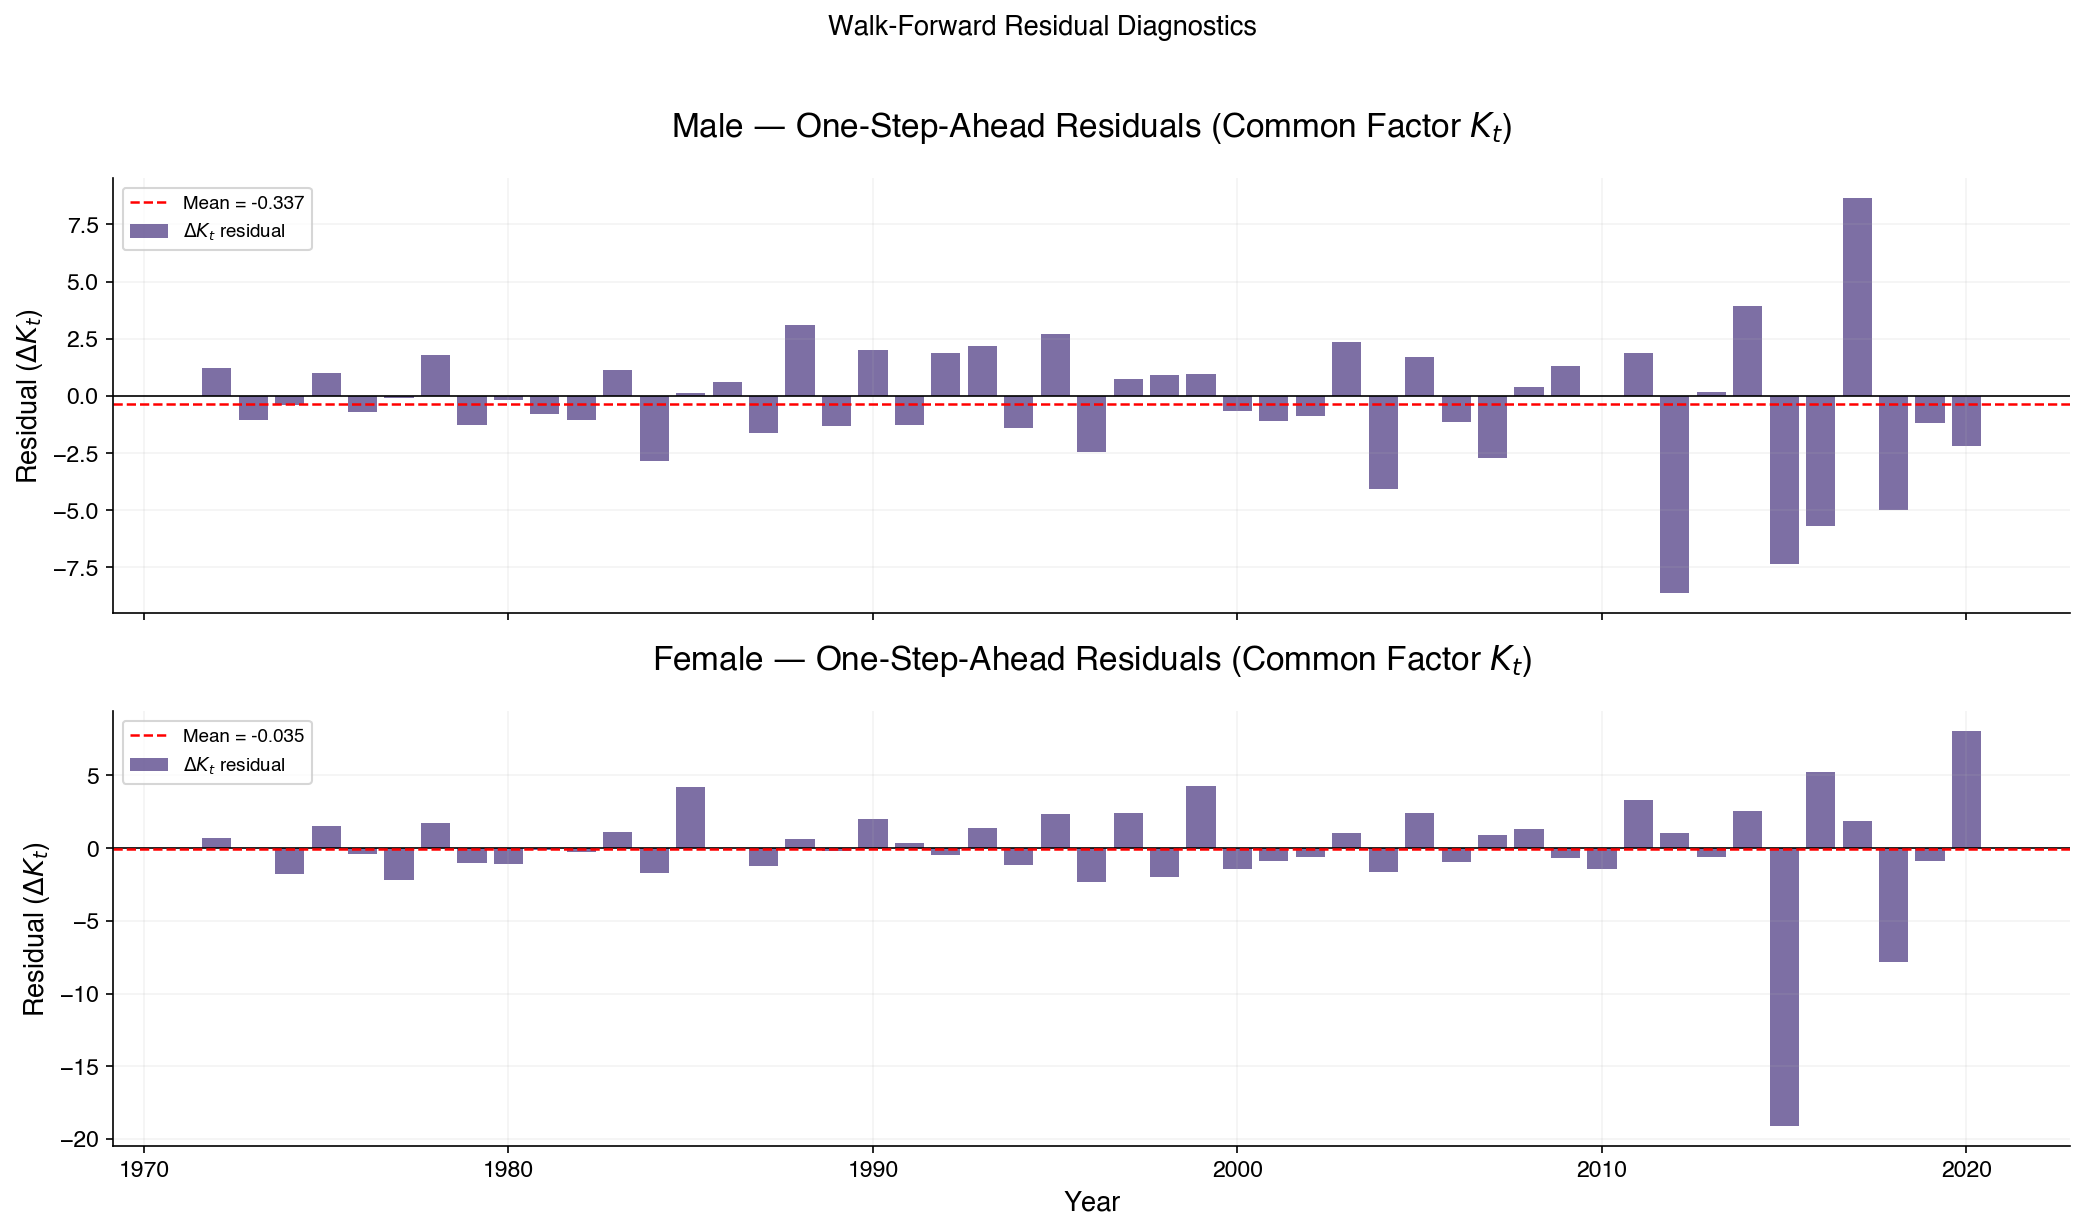

In [3]:
eligible_years = YEARS[LOOKBACK+1:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for sex_idx, (sex, residuals) in enumerate([('Male', res_male), ('Female', res_female)]):
    ax = axes[sex_idx]
    ax.bar(eligible_years, residuals[:, 0], color=COUNTRY_COLORS['CHE'], alpha=0.7, label='$\\Delta K_t$ residual')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axhline(y=residuals[:, 0].mean(), color='red', linewidth=1.2, linestyle='--',
              label=f'Mean = {residuals[:, 0].mean():.3f}')
    ax.set_ylabel('Residual ($\\Delta K_t$)')
    ax.set_title(f'{sex} — One-Step-Ahead Residuals (Common Factor $K_t$)')
    ax.legend(loc='upper left', fontsize=9)
axes[-1].set_xlabel('Year')
fig.suptitle('Walk-Forward Residual Diagnostics', fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig08_residual_diagnostics")
plt.show()

## 4.4: Ensemble MC Dropout Forecast

For each of the 5 models, we run 200 MC Dropout simulations (30 years, recursive). The predictions are averaged across models **in scaled space** before inverse transform and noise addition.

Total effective trajectories: 5 models × 200 simulations = 1,000 trajectories (matching the standard sample size for mortality projections).

In [4]:
N_SIMS_PER_MODEL = 200
N_YEARS_AHEAD = 30  # 2021-2050

def get_initial_sequence(sex, lookback=LOOKBACK):
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    return scaler.transform(data)[-lookback:]

def forecast_mcd_single(model, initial_sequence, n_steps=N_YEARS_AHEAD, n_sims=N_SIMS_PER_MODEL):
    """MC Dropout forecast for a single model. Returns scaled predictions."""
    n_features = initial_sequence.shape[-1]
    all_sims = np.zeros((n_sims, n_steps, n_features))
    for sim in range(n_sims):
        current_seq = initial_sequence.copy()
        for step in range(n_steps):
            inp = tf.convert_to_tensor(current_seq[np.newaxis, ...], dtype=tf.float32)
            pred = model(inp, training=True).numpy().reshape(n_features)
            all_sims[sim, step, :] = pred
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = pred
    return all_sims

init_male = get_initial_sequence('male')
init_female = get_initial_sequence('female')

all_forecasts_male = []
all_forecasts_female = []

t_start = time.time()
for seed in SEEDS:
    print(f"Seed {seed}: forecasting M/F...", end=" ")
    model = ensemble_models[seed]
    all_forecasts_male.append(forecast_mcd_single(model, init_male))
    all_forecasts_female.append(forecast_mcd_single(model, init_female))
    print("done.")

elapsed = time.time() - t_start
print(f"\nAll forecasts complete in {elapsed/60:.1f} minutes.")
print(f"Per-model shape: {all_forecasts_male[0].shape} (sims, steps, features)")
print(f"Total trajectories: {len(SEEDS)} × {N_SIMS_PER_MODEL} = {len(SEEDS) * N_SIMS_PER_MODEL}")

Seed 42: forecasting M/F... 

done.
Seed 77: forecasting M/F... 

done.
Seed 256: forecasting M/F... 

done.
Seed 512: forecasting M/F... 

done.
Seed 1024: forecasting M/F... 

done.

All forecasts complete in 18.4 minutes.
Per-model shape: (200, 30, 8) (sims, steps, features)
Total trajectories: 5 × 200 = 1000


## 4.5: Ensemble Averaging, Inverse Transform & Corrected Noise

Average the 5 models' scaled predictions (simulation-wise), inverse transform to original scale, then add residual-calibrated process noise.

In [5]:
# Average across models in scaled space: (5, 200, 30, 8) → (200, 30, 8)
ensemble_male_scaled = np.mean(np.stack(all_forecasts_male, axis=0), axis=0)
ensemble_female_scaled = np.mean(np.stack(all_forecasts_female, axis=0), axis=0)

def inverse_and_add_noise(sims_scaled, sigma_residual):
    """Inverse transform + residual-calibrated process noise."""
    n_sims, n_steps, n_features = sims_scaled.shape
    flat = sims_scaled.reshape(-1, n_features)
    flat_orig = scaler.inverse_transform(flat)
    sims_orig = flat_orig.reshape(n_sims, n_steps, n_features)
    sims_with_noise = sims_orig.copy()
    for t in range(n_steps):
        noise = np.random.normal(0, sigma_residual, size=(n_sims, n_features))
        sims_with_noise[:, t, :] += noise
    return sims_with_noise

set_seed(42)  # Reproducible noise
sims_male_orig = inverse_and_add_noise(ensemble_male_scaled, sigma_res_male)
sims_female_orig = inverse_and_add_noise(ensemble_female_scaled, sigma_res_female)

print(f"Ensemble predictions (after averaging + noise): {sims_male_orig.shape}")
print(f"Process noise σ (Kt): Male={sigma_res_male[0]:.4f}, Female={sigma_res_female[0]:.4f}")

Ensemble predictions (after averaging + noise): (200, 30, 8)
Process noise σ (Kt): Male=2.8026, Female=3.6356


## 4.6: Level Reconstruction & Mean-Bias Correction (MBC)

Integrate first-difference forecasts back to $K_t$ levels, then apply MBC. MBC corrects the systematic drift that accumulates in recursive forecasts:
$$\hat{\Delta}_t^{MBC} = \hat{\Delta}_t^{LSTM} + \underbrace{(\mu_{Li-Lee} - \mu_{LSTM})}_{\mathcal{B}}$$

This is equivalent to Bayesian shrinkage toward the Li-Lee drift prior.

In [6]:
def integrate_to_levels(sims_diffs_orig, sex):
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    last_level_2020 = data[-1]
    n_sims, n_steps, n_features = sims_diffs_orig.shape
    levels = np.zeros((n_sims, n_steps + 1, n_features))
    levels[:, 0, :] = last_level_2020
    for t in range(1, n_steps + 1):
        levels[:, t, :] = levels[:, t-1, :] + sims_diffs_orig[:, t-1, :]
    return levels

def apply_mbc(sims_diffs_orig, sex):
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), 0.0 if sex == 'male' else 1.0)
    ])
    train_diffs = np.diff(data[:TRAIN_SPLIT_IDX], axis=0)
    mu_li_lee = train_diffs.mean(axis=0)
    mu_ainn = sims_diffs_orig.mean(axis=(0, 1))
    bias = mu_li_lee - mu_ainn
    return sims_diffs_orig + bias[np.newaxis, np.newaxis, :], bias

# Levels (without MBC)
levels_male = integrate_to_levels(sims_male_orig, 'male')
levels_female = integrate_to_levels(sims_female_orig, 'female')

# MBC
sims_male_mbc, bias_male = apply_mbc(sims_male_orig, 'male')
sims_female_mbc, bias_female = apply_mbc(sims_female_orig, 'female')
levels_male_mbc = integrate_to_levels(sims_male_mbc, 'male')
levels_female_mbc = integrate_to_levels(sims_female_mbc, 'female')

forecast_years = np.array([YEARS[-1]] + list(range(YEARS[-1]+1, YEARS[-1]+N_YEARS_AHEAD+1)))
kt_male_sims = levels_male[:, :, 0]
kt_female_sims = levels_female[:, :, 0]

print(f"Level arrays: {levels_male.shape} — (sims, years+1, features)")
print(f"Kt male range (2050):   [{kt_male_sims[:,-1].min():.2f}, {kt_male_sims[:,-1].max():.2f}]")
print(f"Kt female range (2050): [{kt_female_sims[:,-1].min():.2f}, {kt_female_sims[:,-1].max():.2f}]")
print(f"\nMBC bias vectors:")
print(f"  Male Kt:   {bias_male[0]:.4f}")
print(f"  Female Kt: {bias_female[0]:.4f}")

Level arrays: (200, 31, 8) — (sims, years+1, features)
Kt male range (2050):   [-76.66, 2.53]
Kt female range (2050): [-75.68, 38.19]

MBC bias vectors:
  Male Kt:   0.8732
  Female Kt: 1.5553


## 4.7: Stochastic $K_t$ Fan Charts

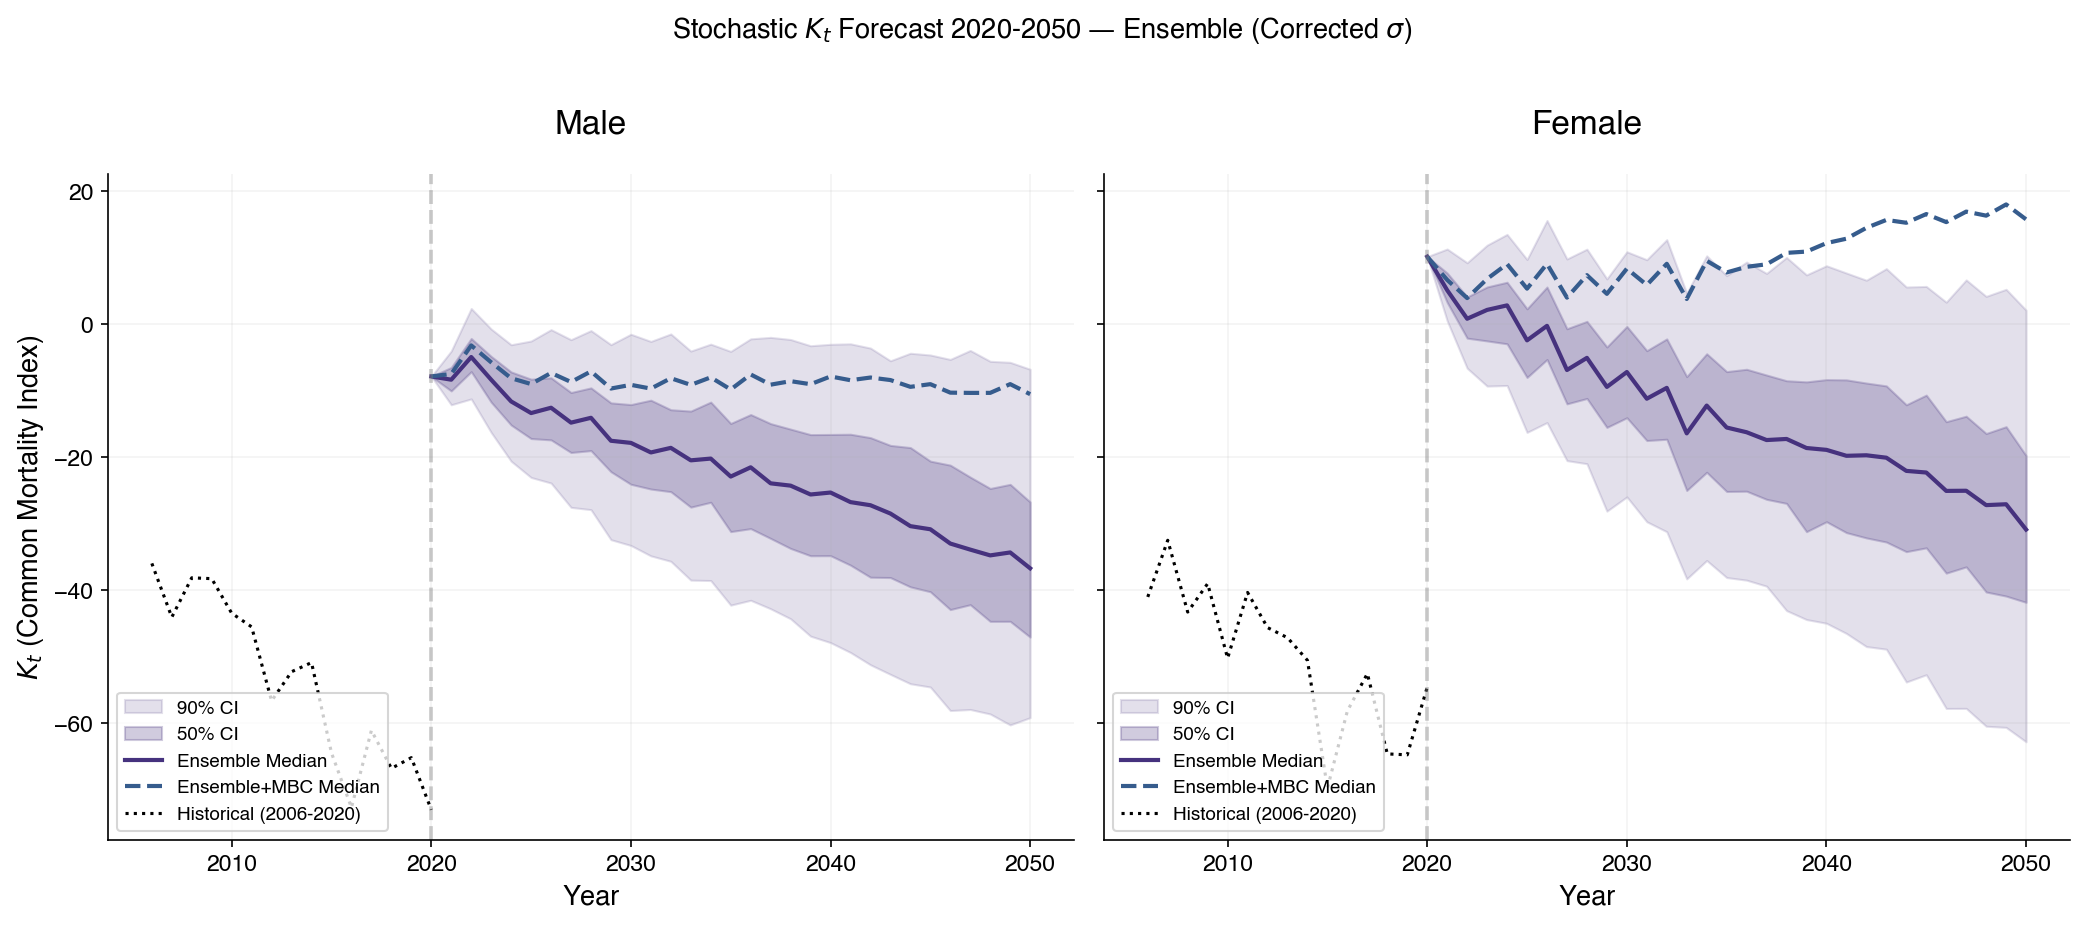

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for sex_idx, (sex, kt_sims, kt_mbc) in enumerate([
    ('Male', kt_male_sims, levels_male_mbc[:, :, 0]),
    ('Female', kt_female_sims, levels_female_mbc[:, :, 0])
]):
    ax = axes[sex_idx]
    p5  = np.percentile(kt_sims, 5, axis=0)
    p25 = np.percentile(kt_sims, 25, axis=0)
    p50 = np.percentile(kt_sims, 50, axis=0)
    p75 = np.percentile(kt_sims, 75, axis=0)
    p95 = np.percentile(kt_sims, 95, axis=0)
    p50_mbc = np.percentile(kt_mbc, 50, axis=0)
    ax.fill_between(forecast_years, p5, p95, alpha=0.15, color=COUNTRY_COLORS['CHE'], label='90% CI')
    ax.fill_between(forecast_years, p25, p75, alpha=0.25, color=COUNTRY_COLORS['CHE'], label='50% CI')
    ax.plot(forecast_years, p50, color=COUNTRY_COLORS['CHE'], linewidth=2, label='Ensemble Median')
    ax.plot(forecast_years, p50_mbc, color=COUNTRY_COLORS['SWE'], linewidth=2,
            linestyle='--', label='Ensemble+MBC Median')
    kt_hist = common_factors[sex.lower()]['Kt']
    ax.plot(YEARS[-15:], kt_hist[-15:], color='black', linewidth=1.5,
            linestyle=':', label='Historical (2006-2020)')
    ax.axvline(x=YEARS[-1], color='grey', linestyle='--', alpha=0.4)
    ax.set_xlabel("Year")
    ax.set_title(sex)
    if sex_idx == 0:
        ax.set_ylabel("$K_t$ (Common Mortality Index)")
    ax.legend(loc='lower left', framealpha=0.8, fontsize=9)
fig.suptitle("Stochastic $K_t$ Forecast 2020-2050 — Ensemble (Corrected $\\sigma$)", fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig10_kt_fan_chart_sex")
plt.show()

## 4.8: Observation-Anchored Life Expectancy Reconstruction

We anchor projections to the **observed mortality at 2020** and apply only the model-predicted cumulative variation in $K_t$:
$$\ln(m_{x,t,i}) = \ln(m_{x,2020,i})^{observed} + B_x \cdot \sum_{\tau=2021}^{t} \Delta K_\tau^{forecast}$$

Country-specific factors are fixed at their 2020 values (Li-Lee stationarity assumption).

**Gompertz Correction**: After reconstruction, isotonic regression is applied on ages 40-90 to enforce strict monotonicity ($m_{x+1} \geq m_x$). This corrects data-inherited granularity artefacts from HMD (typically < 0.001 in magnitude) without altering the model's predictions.


In [8]:
from sklearn.isotonic import IsotonicRegression

def calculate_e0(log_mx):
    mx = np.exp(log_mx)
    qx = 1.0 - np.exp(-mx)
    qx[-1] = 1.0
    px = 1.0 - qx
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    lx_extended = np.append(lx, 0.0)
    return np.sum((lx_extended[:-1] + lx_extended[1:]) / 2.0)

# Isotonic regression for Gompertz compliance (ages 40-90)
_IR = IsotonicRegression(increasing=True)
_AGES_40_90 = np.arange(40, 91)

def reconstruct_e0_anchored(sims_diffs_orig, sex):
    """
    Observation-Anchored Life Expectancy Reconstruction with Gompertz correction.
    
    After reconstructing log-mortality from the cumulative delta_Kt forecast,
    applies isotonic regression on ages 40-90 to enforce strict Gompertz
    monotonicity (m_{x+1} >= m_x). This corrects data-inherited granularity
    artefacts from HMD without altering the model's predictions.
    """
    Bx = common_factors[sex]['Bx']
    n_sims, n_steps = sims_diffs_orig.shape[0], sims_diffs_orig.shape[1]
    n_countries = len(COUNTRIES)
    delta_kt_all = sims_diffs_orig[:, :, 0]
    cumulative_delta_kt = np.cumsum(delta_kt_all, axis=1)
    cumulative_delta_kt = np.concatenate([np.zeros((n_sims, 1)), cumulative_delta_kt], axis=1)
    e0_all = np.zeros((n_sims, n_steps + 1, n_countries))
    for c_idx, code in enumerate(COUNTRIES.keys()):
        log_mx_matrix = np.load(os.path.join(PROCESSED_DIR, f"{code}_log_mx_{sex}.npy"))
        log_mx_2020 = log_mx_matrix[:, -1]
        for s in range(n_sims):
            for t in range(n_steps + 1):
                log_mx_t = log_mx_2020 + Bx * cumulative_delta_kt[s, t]
                # Isotonic Gompertz correction (ages 40-90)
                log_mx_t[40:91] = _IR.fit_transform(_AGES_40_90, log_mx_t[40:91])
                e0_all[s, t, c_idx] = calculate_e0(log_mx_t)
    return e0_all

print("e0 reconstruction function ready (with Gompertz isotonic correction).")


print("Reconstructing e0 (observation-anchored, ensemble, Gompertz-corrected)...")
print("  Male, without MBC...")
e0_male = reconstruct_e0_anchored(sims_male_orig, 'male')
print("  Male, with MBC...")
e0_male_mbc = reconstruct_e0_anchored(sims_male_mbc, 'male')
print("  Female, without MBC...")
e0_female = reconstruct_e0_anchored(sims_female_orig, 'female')
print("  Female, with MBC...")
e0_female_mbc = reconstruct_e0_anchored(sims_female_mbc, 'female')

che_idx = list(COUNTRIES.keys()).index('CHE')
print(f"\ne0 arrays: {e0_male.shape} — (sims, years+1, countries)")
print(f"Sanity check (CHE 2020): Male={e0_male[:, 0, che_idx].mean():.2f}, Female={e0_female[:, 0, che_idx].mean():.2f}")


e0 reconstruction function ready (with Gompertz isotonic correction).
Reconstructing e0 (observation-anchored, ensemble, Gompertz-corrected)...
  Male, without MBC...


  Male, with MBC...


  Female, without MBC...


  Female, with MBC...



e0 arrays: (200, 31, 6) — (sims, years+1, countries)
Sanity check (CHE 2020): Male=80.26, Female=83.58


## 4.9: Life Expectancy Results (2020-2050)

In [9]:
results_table = []
for c_idx, (code, name) in enumerate(COUNTRIES.items()):
    for sex, e0_arr, e0_mbc_arr in [
        ('Male', e0_male, e0_male_mbc),
        ('Female', e0_female, e0_female_mbc)
    ]:
        e0_2020 = e0_arr[:, 0, c_idx].mean()
        e0_2050_med = np.percentile(e0_arr[:, -1, c_idx], 50)
        e0_2050_p25 = np.percentile(e0_arr[:, -1, c_idx], 2.5)
        e0_2050_p975 = np.percentile(e0_arr[:, -1, c_idx], 97.5)
        e0_2050_mbc = np.percentile(e0_mbc_arr[:, -1, c_idx], 50)
        results_table.append({
            'Country': name, 'Sex': sex,
            'e0 (2020)': round(e0_2020, 2),
            'e0 (2050) Median': round(e0_2050_med, 2),
            '95% CI (2050)': f'[{e0_2050_p25:.2f}, {e0_2050_p975:.2f}]',
            'CI Width': round(e0_2050_p975 - e0_2050_p25, 2),
            'e0 (2050) +MBC': round(e0_2050_mbc, 2),
            'Net Gain': round(e0_2050_med - e0_2020, 2),
        })

df_results = pd.DataFrame(results_table)
print("Stochastic Life Expectancy Projections (2020-2050) — Ensemble")
print("=" * 110)
print(df_results.to_string(index=False))

Stochastic Life Expectancy Projections (2020-2050) — Ensemble
     Country    Sex  e0 (2020)  e0 (2050) Median  95% CI (2050)  CI Width  e0 (2050) +MBC  Net Gain
 Switzerland   Male      80.26             82.06 [79.91, 83.60]      3.69           80.44      1.80
 Switzerland Female      83.58             85.55 [83.84, 86.88]      3.03           83.26      1.96
      Sweden   Male      79.94             81.74 [79.58, 83.31]      3.73           80.12      1.80
      Sweden Female      82.93             85.01 [83.20, 86.46]      3.26           82.60      2.08
      Norway   Male      80.58             82.30 [80.24, 83.80]      3.57           80.75      1.73
      Norway Female      83.27             85.28 [83.53, 86.66]      3.13           82.95      2.01
West Germany   Male      78.28             80.35 [77.88, 82.16]      4.28           78.49      2.06
West Germany Female      82.20             84.48 [82.50, 86.05]      3.55           81.84      2.27
 Netherlands   Male      79.14        

## 4.10: Life Expectancy Convergence Plot

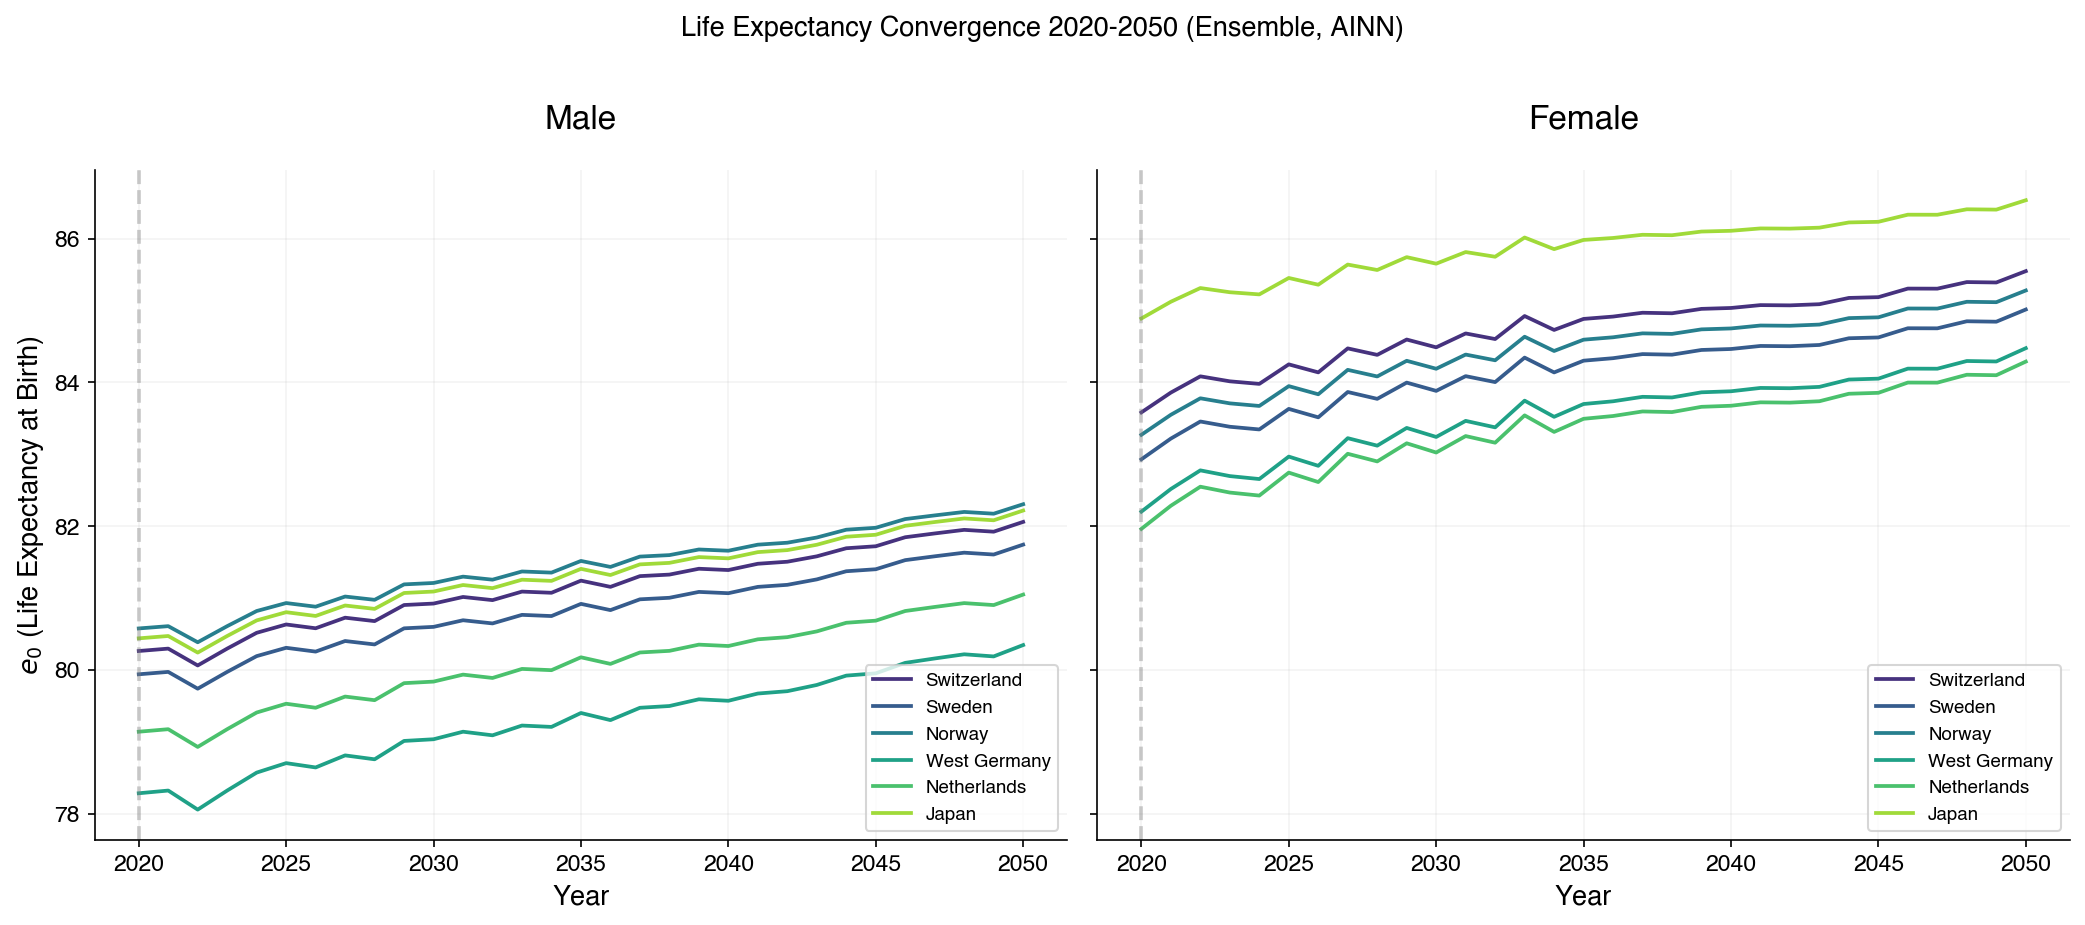

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for sex_idx, (sex, e0_arr) in enumerate([('Male', e0_male), ('Female', e0_female)]):
    ax = axes[sex_idx]
    for c_idx, (code, name) in enumerate(COUNTRIES.items()):
        median_traj = np.percentile(e0_arr[:, :, c_idx], 50, axis=0)
        ax.plot(forecast_years, median_traj, color=COUNTRY_COLORS[code], label=name, linewidth=1.8)
    ax.axvline(x=YEARS[-1], color='grey', linestyle='--', alpha=0.4)
    ax.set_xlabel("Year")
    ax.set_title(sex)
    if sex_idx == 0:
        ax.set_ylabel("$e_0$ (Life Expectancy at Birth)")
    ax.legend(loc='lower right', framealpha=0.8, fontsize=9)
fig.suptitle("Life Expectancy Convergence 2020-2050 (Ensemble, AINN)", fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig11_e0_convergence_sex")
plt.show()

## 4.11: MBC Impact (Switzerland Case Study)

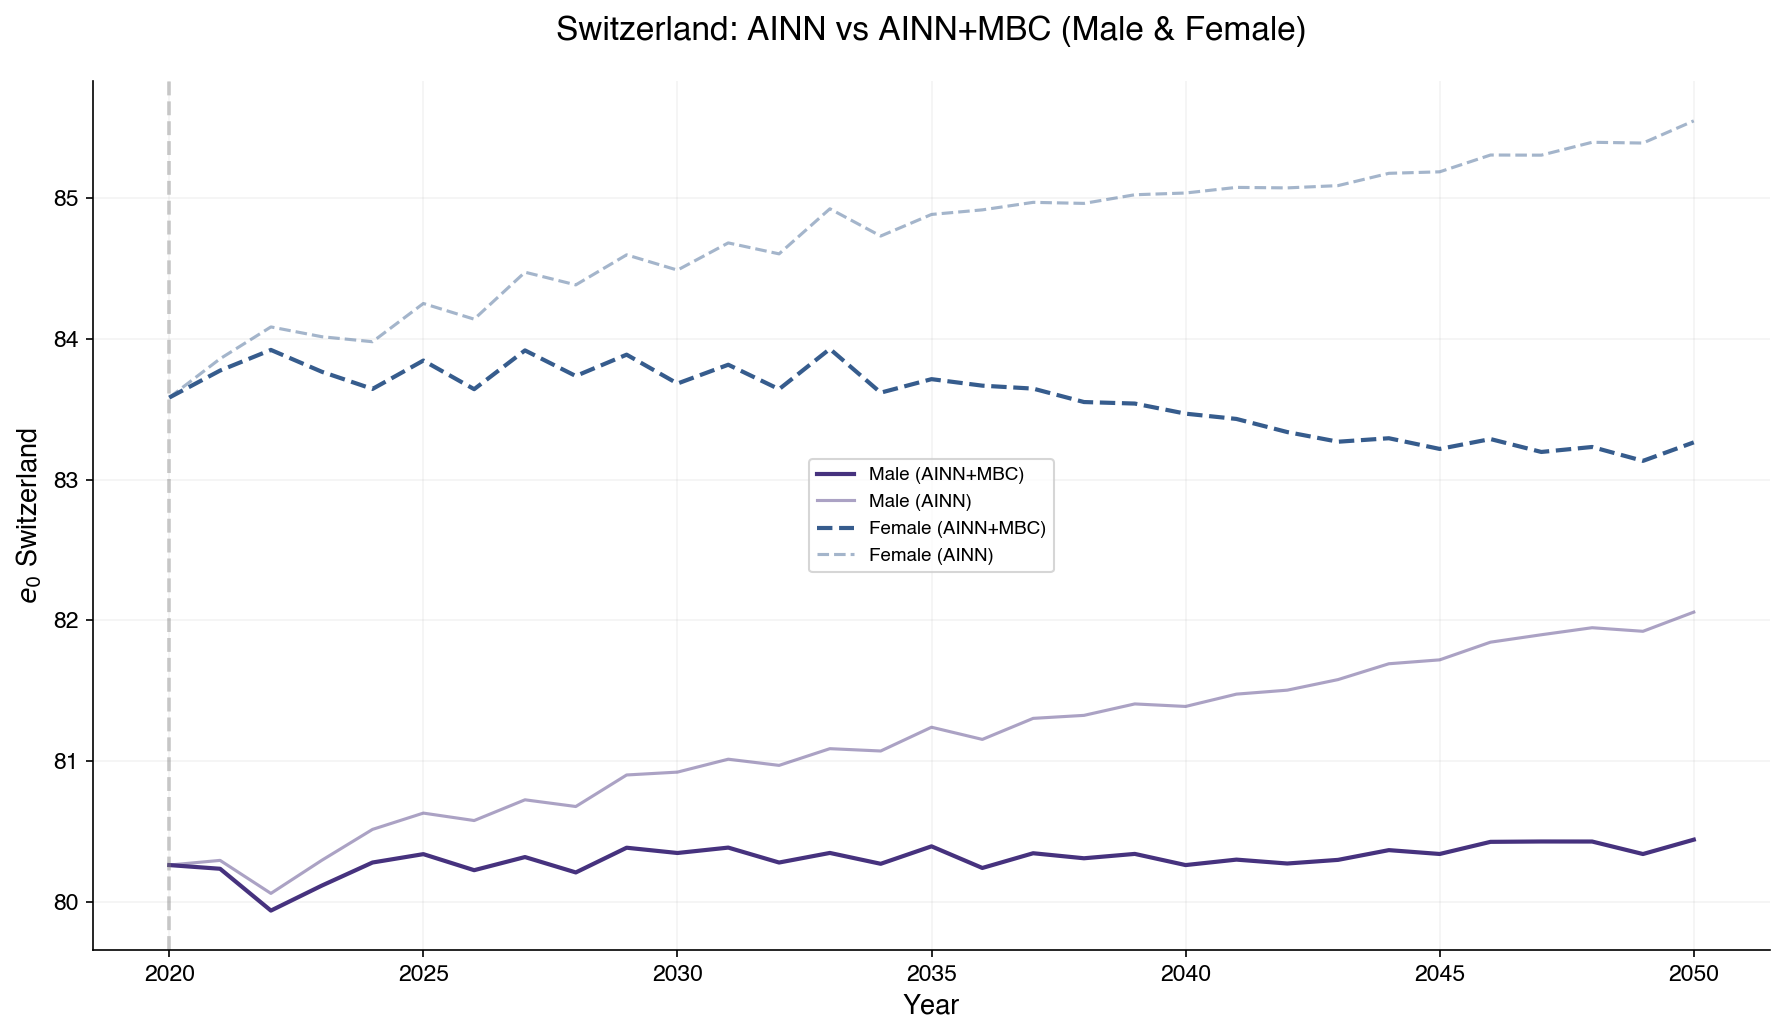

In [11]:
fig, ax = plt.subplots()
for sex, e0_raw, e0_mbc, col, ls in [
    ('Male', e0_male[:, :, che_idx], e0_male_mbc[:, :, che_idx], COUNTRY_COLORS['CHE'], '-'),
    ('Female', e0_female[:, :, che_idx], e0_female_mbc[:, :, che_idx], COUNTRY_COLORS['SWE'], '--')
]:
    raw_med = np.percentile(e0_raw, 50, axis=0)
    mbc_med = np.percentile(e0_mbc, 50, axis=0)
    ax.plot(forecast_years, mbc_med, color=col, linewidth=2, linestyle=ls, label=f'{sex} (AINN+MBC)')
    ax.plot(forecast_years, raw_med, color=col, linewidth=1.5, linestyle=ls, alpha=0.45, label=f'{sex} (AINN)')
ax.axvline(x=YEARS[-1], color='grey', linestyle='--', alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("$e_0$ Switzerland")
ax.set_title("Switzerland: AINN vs AINN+MBC (Male & Female)")
ax.legend(fontsize=9)
plt.tight_layout()
save_dual(fig, "fig12_che_mbc_impact")
plt.show()

## 4.12: Credibility-Weighted MBC with Time-Varying $Z(t)$

The standard MBC applies a constant bias correction $\mathcal{B}$ at every forecast step. This implicitly assigns **full credibility** ($Z=1$) to the LSTM's predictions regardless of the forecast horizon.

In credibility theory (Bühlmann), the weight assigned to an estimator should depend on the **amount of relevant information** available. For recursive forecasting:
- **Near horizon** (2021-2030): the LSTM extrapolates from recent data it has seen during training → high credibility.
- **Far horizon** (2040-2050): the LSTM is deep into extrapolation territory → credibility should decrease, and the weight of the actuarial prior (Li-Lee drift) should increase.

We implement a **time-decaying credibility weight**:
$$Z(t) = e^{-\alpha \cdot t}$$
where $t$ is the forecast step (0 at 2020, 30 at 2050) and $\alpha$ controls the decay rate.

The blended forecast becomes:
$$\hat{\Delta}_t = Z(t) \cdot \hat{\Delta}_t^{LSTM} + (1 - Z(t)) \cdot \mu_{Li-Lee}$$

At $\alpha=0$: $Z=1$ always → pure LSTM (current AINN without MBC).  
At $\alpha \to \infty$: $Z=0$ always → pure Li-Lee drift.  
At moderate $\alpha$: the model transitions smoothly from neural to actuarial.


In [ ]:
def apply_credibility_mbc(sims_diffs_orig, sex, alpha):
    """
    Time-varying credibility-weighted MBC.
    
    Z(t) = exp(-alpha * t) — credibility decays with forecast horizon.
    Blended forecast: Z(t) * LSTM + (1 - Z(t)) * Li-Lee drift.
    """
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), 0.0 if sex == 'male' else 1.0)
    ])
    train_diffs = np.diff(data[:TRAIN_SPLIT_IDX], axis=0)
    mu_lilee = train_diffs.mean(axis=0)  # Li-Lee historical drift
    
    n_sims, n_steps, n_features = sims_diffs_orig.shape
    blended = np.zeros_like(sims_diffs_orig)
    
    for t in range(n_steps):
        z = np.exp(-alpha * t)  # Credibility weight
        blended[:, t, :] = z * sims_diffs_orig[:, t, :] + (1 - z) * mu_lilee
    
    return blended

# Test several alpha values
alphas = [0.0, 0.02, 0.05, 0.1, 0.2]
che_idx = list(COUNTRIES.keys()).index('CHE')

print('Credibility-Weighted MBC — Z(t) = exp(-α·t)')
print('='*90)
print(f'{"α":>6} {"Z(2025)":>8} {"Z(2035)":>8} {"Z(2050)":>8} '
      f'{"CHE M Med":>10} {"CHE F Med":>10} {"CHE M CI":>9} {"CHE F CI":>9}')
print('-'*90)

for alpha in alphas:
    # Blend and integrate
    blended_m = apply_credibility_mbc(sims_male_orig, 'male', alpha)
    blended_f = apply_credibility_mbc(sims_female_orig, 'female', alpha)
    
    levels_m = integrate_to_levels(blended_m, 'male')
    levels_f = integrate_to_levels(blended_f, 'female')
    
    # e0 reconstruction (using same function from above)
    e0_m = reconstruct_e0_anchored(blended_m, 'male')
    e0_f = reconstruct_e0_anchored(blended_f, 'female')
    
    med_m = np.percentile(e0_m[:, -1, che_idx], 50)
    med_f = np.percentile(e0_f[:, -1, che_idx], 50)
    ci_m = np.percentile(e0_m[:, -1, che_idx], 97.5) - np.percentile(e0_m[:, -1, che_idx], 2.5)
    ci_f = np.percentile(e0_f[:, -1, che_idx], 97.5) - np.percentile(e0_f[:, -1, che_idx], 2.5)
    
    z5 = np.exp(-alpha * 5)
    z15 = np.exp(-alpha * 15)
    z30 = np.exp(-alpha * 30)
    
    label = 'LSTM only' if alpha == 0 else f'{alpha}'
    print(f'{label:>6} {z5:>8.3f} {z15:>8.3f} {z30:>8.3f} '
          f'{med_m:>10.2f} {med_f:>10.2f} {ci_m:>9.2f} {ci_f:>9.2f}')

print()
print('Interpretation:')
print('  α=0.0:  Pure LSTM (no MBC). Maximum responsiveness to learned dynamics.')
print('  α=0.02: Mild decay. Z(2050)=0.55 — LSTM still dominant at 30yr horizon.')
print('  α=0.05: Moderate. Z(2050)=0.22 — transitions to Li-Lee drift for long horizons.')
print('  α=0.1:  Strong. Z(2050)=0.05 — mostly actuarial prior beyond 20 years.')
print('  α=0.2:  Very strong. Essentially Li-Lee drift beyond 10 years.')
print()
print('The credibility framework provides a principled mechanism to blend')
print('neural predictions (strong near-term) with actuarial priors (stable long-term).')
print('The α parameter is interpretable: it represents the risk manager\'s confidence')
print('in the neural model\'s ability to extrapolate beyond its training horizon.')


## 4.13: Cross-Project Comparison (P04 Total vs P05 Synthetic Total)

To enable direct comparison with Project 04 (which models both-sexes-combined "Total" mortality), we compute a **synthetic Total** from the P05 sex-specific projections as the simple average of Male and Female $e_0$.

This answers the question: *are the P05 sex-specific results consistent with P04's aggregated results?*


## 4.14: Multi-Step Constraint Effect (Constrained vs Unconstrained)

The AINN constraints (coherence + monotonicity) have a neutral effect on one-step-ahead RMSE (-0.009%). But do they matter for **recursive 30-year forecasting**?

We compare the constrained ensemble forecast (above) with a forecast from the unconstrained baseline model (same architecture, lb=15, trained without λ penalties). If the constraints stabilise the recursive trajectory, we should see divergence at long horizons.


In [12]:
# Load unconstrained baseline model (saved in NB03)
baseline_path = os.path.join(MODELS_DIR, 'ainn_unconstrained_baseline.keras')
if os.path.exists(baseline_path):
    baseline_model = keras.models.load_model(baseline_path, compile=False)
    
    # Forecast with baseline (single model, 200 sims, same σ)
    print('Running unconstrained baseline forecast (200 sims)...')
    bl_male_scaled = forecast_mcd_single(baseline_model, init_male)
    bl_female_scaled = forecast_mcd_single(baseline_model, init_female)
    
    set_seed(42)
    bl_male_orig = inverse_and_add_noise(bl_male_scaled, sigma_res_male)
    bl_female_orig = inverse_and_add_noise(bl_female_scaled, sigma_res_female)
    
    # Reconstruct e0 for baseline
    print('Reconstructing e0 (unconstrained baseline)...')
    bl_e0_male = reconstruct_e0_anchored(bl_male_orig, 'male')
    bl_e0_female = reconstruct_e0_anchored(bl_female_orig, 'female')
    
    # Compare at key horizons: 2030, 2040, 2050
    print()
    print('Multi-Step Constraint Effect — Switzerland (CHE)')
    print('=' * 90)
    print(f"{'Horizon':<10} {'Constrained M':>14} {'Unconstr. M':>14} {'Δ M':>8} {'Constrained F':>14} {'Unconstr. F':>14} {'Δ F':>8}")
    print('-' * 90)
    
    for year, t_idx in [(2030, 10), (2040, 20), (2050, 30)]:
        c_med_m = np.percentile(e0_male[:, t_idx, che_idx], 50)
        b_med_m = np.percentile(bl_e0_male[:, t_idx, che_idx], 50)
        c_med_f = np.percentile(e0_female[:, t_idx, che_idx], 50)
        b_med_f = np.percentile(bl_e0_female[:, t_idx, che_idx], 50)
        print(f'{year:<10} {c_med_m:>14.3f} {b_med_m:>14.3f} {c_med_m - b_med_m:>+8.3f} {c_med_f:>14.3f} {b_med_f:>14.3f} {c_med_f - b_med_f:>+8.3f}')
    
    # CI comparison at 2050
    print()
    print('95% CI Width at 2050 (CHE):')
    for sex, c_e0, b_e0 in [('Male', e0_male, bl_e0_male), ('Female', e0_female, bl_e0_female)]:
        c_ci = np.percentile(c_e0[:, -1, che_idx], 97.5) - np.percentile(c_e0[:, -1, che_idx], 2.5)
        b_ci = np.percentile(b_e0[:, -1, che_idx], 97.5) - np.percentile(b_e0[:, -1, che_idx], 2.5)
        print(f'  {sex}: Constrained={c_ci:.3f}, Unconstrained={b_ci:.3f}, Δ={c_ci - b_ci:+.3f}')
    
    print()
    print('Note: The constrained model is the 5-seed ensemble; the unconstrained is a single')
    print('model (seed 42, same architecture, no λ penalties). Differences reflect both the')
    print('constraint effect and the ensemble averaging.')
else:
    print(f'Unconstrained baseline not found at {baseline_path}.')
    print('Run Notebook 03 first to generate the baseline model.')


Running unconstrained baseline forecast (200 sims)...


Reconstructing e0 (unconstrained baseline)...



Multi-Step Constraint Effect — Switzerland (CHE)
Horizon     Constrained M    Unconstr. M      Δ M  Constrained F    Unconstr. F      Δ F
------------------------------------------------------------------------------------------
2030               80.923         80.888   +0.035         84.487         84.422   +0.065
2040               81.389         81.318   +0.072         85.034         85.293   -0.259
2050               82.059         82.047   +0.012         85.547         85.862   -0.316

95% CI Width at 2050 (CHE):
  Male: Constrained=3.695, Unconstrained=4.017, Δ=-0.322
  Female: Constrained=3.034, Unconstrained=3.146, Δ=-0.113

Note: The constrained model is the 5-seed ensemble; the unconstrained is a single
model (seed 42, same architecture, no λ penalties). Differences reflect both the
constraint effect and the ensemble averaging.


## 4.15: Persistence

In [13]:
# Load P04 results
p04_data = np.load(os.path.join('../../04_Multi_Population_Longevity_XAI/data/processed/',
                                 'stochastic_forecast_results.npz'), allow_pickle=True)
p04_e0 = p04_data['e0_sims_all']  # (6, 1000, 31) — countries, sims, years
p04_codes = list(p04_data['country_codes'])

# Compute P05 synthetic Total: average of Male and Female e0
# e0_male and e0_female are (200, 31, 6)
e0_total_synthetic = (e0_male + e0_female) / 2.0  # (200, 31, 6)

print('Cross-Project Comparison: P04 (Total) vs P05 (Synthetic Total = avg M/F)')
print('=' * 100)
print(f"{'Country':<15} {'P04 e0(2020)':>12} {'P05 e0(2020)':>12} {'P04 e0(2050)':>12} {'P05 e0(2050)':>12} {'P04 CI':>10} {'P05 CI':>10}")
print('-' * 100)

for c_idx, (code, name) in enumerate(COUNTRIES.items()):
    # P04
    p04_cidx = p04_codes.index(code)
    p04_2020 = p04_e0[p04_cidx, :, 0].mean()
    p04_med = np.percentile(p04_e0[p04_cidx, :, -1], 50)
    p04_p25 = np.percentile(p04_e0[p04_cidx, :, -1], 2.5)
    p04_p975 = np.percentile(p04_e0[p04_cidx, :, -1], 97.5)
    p04_ci = p04_p975 - p04_p25
    
    # P05 synthetic total
    p05_2020 = e0_total_synthetic[:, 0, c_idx].mean()
    p05_med = np.percentile(e0_total_synthetic[:, -1, c_idx], 50)
    p05_p25 = np.percentile(e0_total_synthetic[:, -1, c_idx], 2.5)
    p05_p975 = np.percentile(e0_total_synthetic[:, -1, c_idx], 97.5)
    p05_ci = p05_p975 - p05_p25
    
    print(f'{name:<15} {p04_2020:>12.2f} {p05_2020:>12.2f} {p04_med:>12.2f} {p05_med:>12.2f} {p04_ci:>10.2f} {p05_ci:>10.2f}')

print()
print('Note: P05 synthetic Total = (Male e0 + Female e0) / 2.')
print('P04 uses both-sexes-combined mortality directly (different methodology).')
print('Differences reflect: (1) sex-specific decomposition, (2) lookback 15 vs 10,')
print('(3) residual-calibrated σ vs historical σ, (4) ensemble vs single seed.')


Cross-Project Comparison: P04 (Total) vs P05 (Synthetic Total = avg M/F)
Country         P04 e0(2020) P05 e0(2020) P04 e0(2050) P05 e0(2050)     P04 CI     P05 CI
----------------------------------------------------------------------------------------------------
Switzerland            81.71        81.92        84.78        83.78       1.85       2.36
Sweden                 81.71        81.43        84.74        83.37       1.84       2.43
Norway                 81.53        81.92        84.63        83.78       1.88       2.33
West Germany           80.37        80.24        83.83        82.39       2.11       2.75
Netherlands            81.30        80.55        84.47        82.66       1.93       2.65
Japan                  81.72        82.66        84.79        84.36       1.85       2.21

Note: P05 synthetic Total = (Male e0 + Female e0) / 2.
P04 uses both-sexes-combined mortality directly (different methodology).
Differences reflect: (1) sex-specific decomposition, (2) lookback 1

In [14]:
forecasting_assets = {
    # Kt level trajectories
    "kt_male_sims": kt_male_sims,
    "kt_female_sims": kt_female_sims,
    "kt_male_mbc": levels_male_mbc[:, :, 0],
    "kt_female_mbc": levels_female_mbc[:, :, 0],
    # e0 trajectories
    "e0_male": e0_male,
    "e0_female": e0_female,
    "e0_male_mbc": e0_male_mbc,
    "e0_female_mbc": e0_female_mbc,
    # Metadata
    "forecast_years": forecast_years,
    "n_sims": N_SIMS_PER_MODEL,
    "n_models": len(SEEDS),
    "n_years_ahead": N_YEARS_AHEAD,
    "seeds": SEEDS,
    "bias_male": bias_male,
    "bias_female": bias_female,
    "process_std_male": sigma_res_male,
    "process_std_female": sigma_res_female,
    "process_std_male_historical": sigma_hist_male,
    "process_std_female_historical": sigma_hist_female,
    "residuals_male": res_male,
    "residuals_female": res_female,
    "countries": list(COUNTRIES.keys()),
    "e0_total_synthetic": e0_total_synthetic,
    "method": "ensemble_5seed_corrected_sigma_isotonic",
}

with open(os.path.join(PROCESSED_DIR, "forecasting_assets.pkl"), "wb") as f:
    pickle.dump(forecasting_assets, f)

df_results.to_csv(os.path.join(PROCESSED_DIR, "e0_projections_summary.csv"), index=False)

print("Forecasting assets saved:")
print(f"  {PROCESSED_DIR}forecasting_assets.pkl")
print(f"  {PROCESSED_DIR}e0_projections_summary.csv")
print(f"\nNotebook 04 complete. Proceed to Notebook 05 (XAI & Validation).")

Forecasting assets saved:
  ../data/processed/forecasting_assets.pkl
  ../data/processed/e0_projections_summary.csv

Notebook 04 complete. Proceed to Notebook 05 (XAI & Validation).
